# 🧹 ใบงานสัปดาห์ที่ 03 — การทำความสะอาดและจัดเตรียมข้อมูล (Data Cleaning & Preprocessing)

---

**รายวิชา:** 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล | ภาคการศึกษา 1/2569  
**รหัสกลุ่ม:** TEAM-99  
**สมาชิกกลุ่ม:**  
1. น.ส.กมลวรรณ จันทร์ผึ้ง (001)  
2. น.ส.ชลดา อิศรเสนา ณ อยุธยา (009)  
3. น.ส.ณัฐพร เผือกผ่อง (016)  
**หัวข้อโครงงาน:** AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (JobSatisfaction)  
**ชุดข้อมูล:** IBM HR Analytics Employee Attrition & Performance (1,470 แถว × 35 คอลัมน์)  

---

### 📌 วัตถุประสงค์และภาพรวม
ตรวจสอบค่าว่าง (Missing Values) จัดการ Outlier ของรายได้ต่อเดือน (MonthlyIncome) ด้วยเกณฑ์ IQR และ Clipping สร้างฟีเจอร์ใหม่ TotalSatisfaction และทำ One-Hot Encoding รวมถึงการ Scaling ข้อมูล


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


In [1]:
# Dataset พร้อมใช้งานผ่าน Auto-Setup แล้ว
# from google.colab import files
# files.upload()
print("✓ ใช้ข้อมูลจากระบบ Auto-Setup เรียบร้อยแล้ว")


✓ ใช้ข้อมูลจากระบบ Auto-Setup เรียบร้อยแล้ว


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset --unzip -p data/


Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
100% 50.1k/50.1k [00:00<00:00, 49.1MB/s]



In [ ]:
import pandas as pd
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape
df.info()
df.describe()

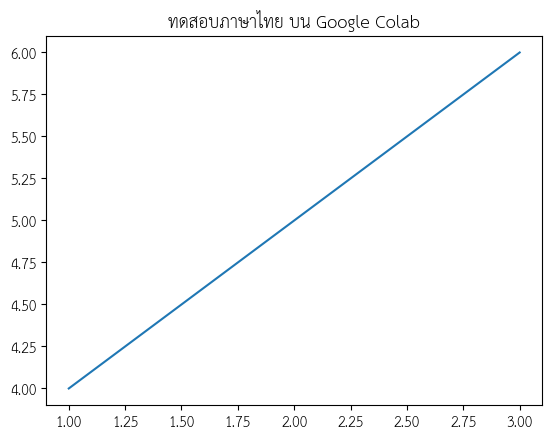

In [5]:
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (หากยังไม่ได้ดาวน์โหลด)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt

# 2. แก้ไขจุดนี้: เรียกผ่าน fontManager (มี M ตัวใหญ่)
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

# 3. กำหนดให้เป็นฟอนต์หลัก
mpl.rc('font', family='TH Sarabun New')

# 4. ทดสอบวาดกราฟภาษาไทย
plt.title("ทดสอบภาษาไทย บน Google Colab")
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

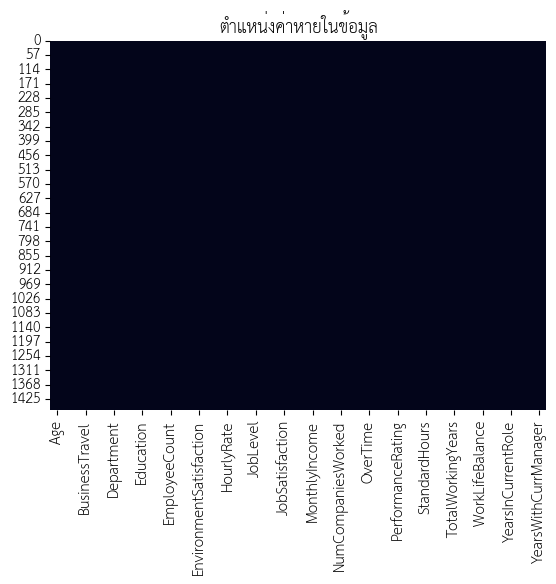

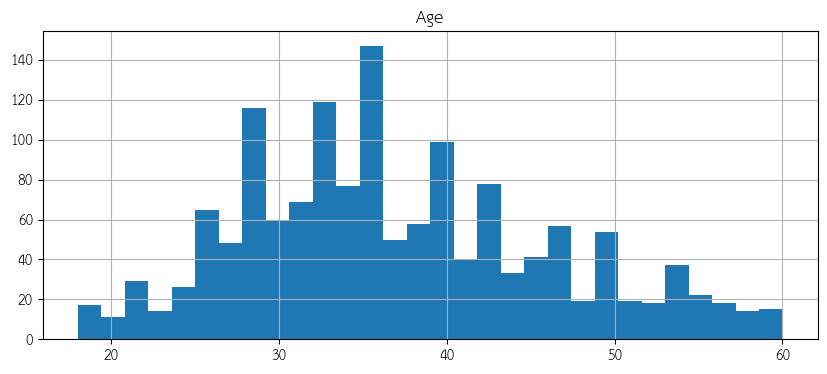

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.isnull(), cbar=False)
plt.title('ตำแหน่งค่าหายในข้อมูล')
plt.show()

df[['Age']].hist(figsize=(10,4), bins=30)
plt.show()

In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Attrition'] = df['Attrition'].fillna(df['Attrition'].mode()[0])

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


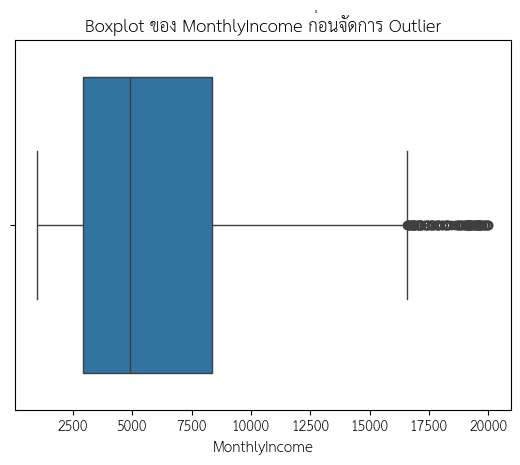

ขอบบนที่ยอมรับได้: 16581.0
จำนวนแถวที่เกินขอบบน: 114


In [11]:
sns.boxplot(x=df['MonthlyIncome'])
plt.title("Boxplot ของ MonthlyIncome ก่อนจัดการ Outlier")
plt.show()

Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
print("ขอบบนที่ยอมรับได้:", upper)
print("จำนวนแถวที่เกินขอบบน:", (df["MonthlyIncome"] > upper).sum())

เลือก MonthlyIncome เพราะว่า มีค่าที่สูงผิดปกติอยู่บางจุด

```
# มีการจัดรูปแบบเป็นโค้ด
```



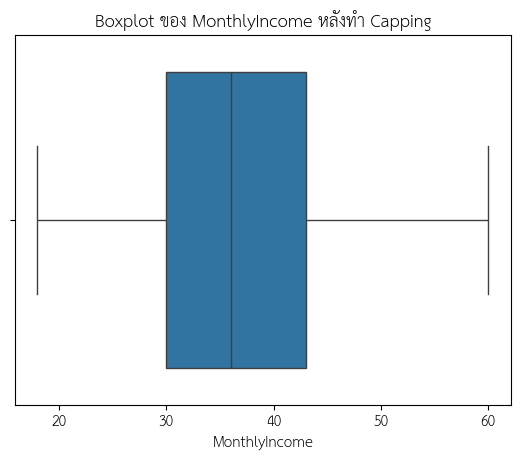

In [12]:
df["MonthlyIncome"] = df["MonthlyIncome"].clip(upper=upper)

sns.boxplot(x=df["MonthlyIncome"])
plt.title("Boxplot ของ MonthlyIncome หลังทำ Capping")
plt.show()

In [13]:
print("ก่อนลบ:", df.shape)
df = df.drop_duplicates()
print("หลังลบ:", df.shape)

ก่อนลบ: (1470, 35)
หลังลบ: (1470, 35)


In [14]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# **Encode**

In [15]:
df["TotalSatisfaction"] = df["JobSatisfaction"] + df["EnvironmentSatisfaction"] + df["RelationshipSatisfaction"]

df[["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "TotalSatisfaction"]].head()

,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,TotalSatisfaction
0,4,2,1,7
1,2,3,4,9
2,3,4,2,9
3,3,4,3,10
4,2,1,4,7


In [16]:
df["BusinessTravel"].value_counts()


,count
BusinessTravel,
Travel_Rarely,1043
Travel_Frequently,277
Non-Travel,150


In [17]:
df["Department"].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [18]:
df["EducationField"].value_counts()

,count
EducationField,
Life Sciences,606
Medical,464
Marketing,159
Technical Degree,132
Other,82
Human Resources,27


In [19]:
df = pd.get_dummies(df, columns=["Department", "EducationField"])
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalSatisfaction,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,Yes,Travel_Rarely,1102,1,2,1,1,2,Female,...,7,False,False,True,False,True,False,False,False,False
1,49,No,Travel_Frequently,279,8,1,1,2,3,Male,...,9,False,True,False,False,True,False,False,False,False
2,37,Yes,Travel_Rarely,1373,2,2,1,4,4,Male,...,9,False,True,False,False,False,False,False,True,False
3,33,No,Travel_Frequently,1392,3,4,1,5,4,Female,...,10,False,True,False,False,True,False,False,False,False
4,27,No,Travel_Rarely,591,2,1,1,7,1,Male,...,7,False,True,False,False,False,False,True,False,False


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ["Age", "DailyRate"]
df[cols] = scaler.fit_transform(df[cols])
df[cols].describe()

,Age,DailyRate
count,1470.000000,1470.000000
mean,0.450567,0.501421
std,0.217509,0.288840
min,0.000000,0.000000
25%,0.285714,0.259843
50%,0.428571,0.501074
75%,0.595238,0.755190
max,1.000000,1.000000


In [21]:
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
df_std = df.copy()
cols = ["Age", "DailyRate"]
df_std[cols] = scaler2.fit_transform(df_std[cols])
df_std[cols].describe()

,Age,DailyRate
count,1.470000e+03,1.470000e+03
mean,8.579683e-17,-3.866899e-17
std,1.000340e+00,1.000340e+00
min,-2.072192e+00,-1.736576e+00
25%,-7.581700e-01,-8.366616e-01
50%,-1.011589e-01,-1.204135e-03
75%,6.653541e-01,8.788772e-01
max,2.526886e+00,1.726730e+00


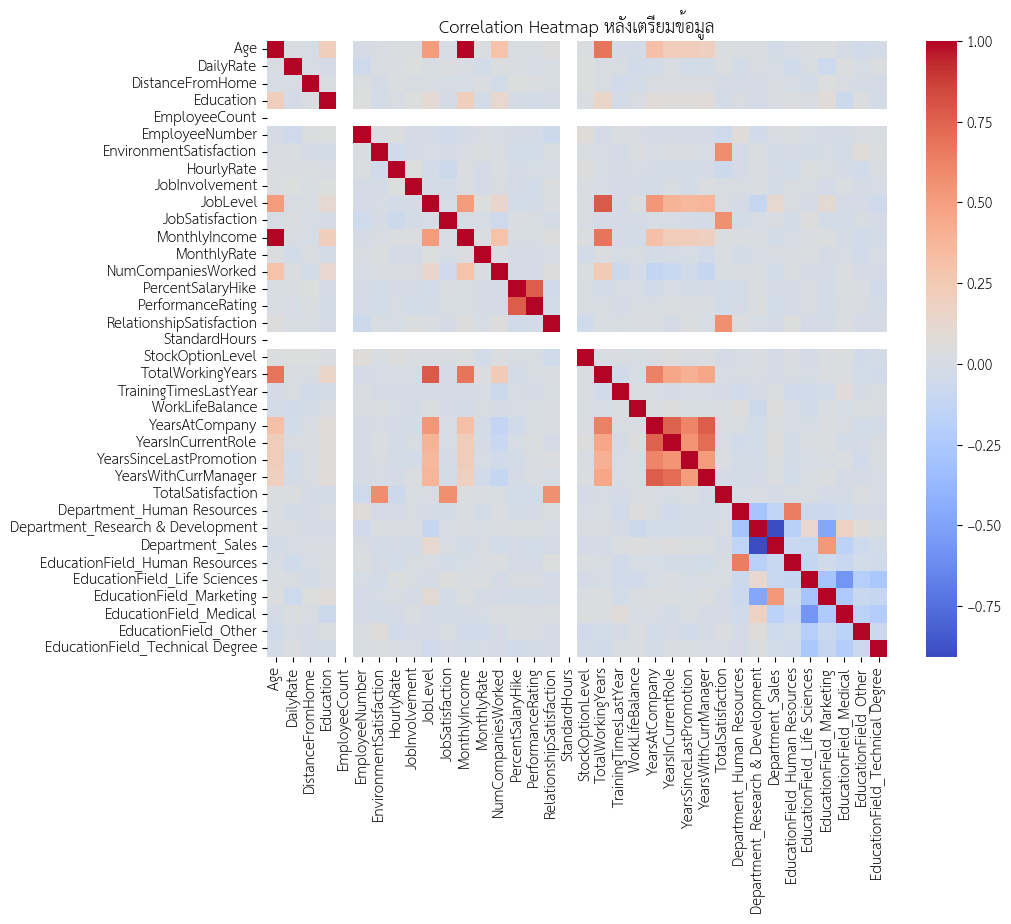

0 ค่าหายที่เหลือ


In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap หลังเตรียมข้อมูล")
plt.show()

print(df.isnull().sum().sum(), "ค่าหายที่เหลือ")

df.to_csv("clean.csv", index=False)

---

## 📝 สรุปผลและตอบคำถามวัดความเข้าใจตามใบงาน

### สรุปคำถามและการวิเคราะห์:
1. **การจัดการ Outlier:** ใช้เกณฑ์ IQR (1.5 × IQR) สำหรับตัวแปร MonthlyIncome โดยทำ Clipping ค่าบนที่ขอบเขต Q3 + 1.5×IQR เพื่อไม่ให้ค่าผิดปกติส่งผลเสียต่อการเรียนรู้ของโมเดล
2. **การสร้างฟีเจอร์ใหม่ (Feature Engineering):** รวมค่า JobSatisfaction + EnvironmentSatisfaction + RelationshipSatisfaction เป็น  เพื่อวัดความพึงพอใจโดยรวมของพนักงาน
3. **การแปลงข้อมูลตัวอักษร (Encoding):** ใช้ One-Hot Encoding กับคอลัมน์ Department, EducationField, BusinessTravel
4. **การบันทึกไฟล์คลีน:** บันทึกชุดข้อมูลพร้อมใช้งานเป็น clean.csv
